# Multi-Output Time-series Forecasting (Dataset - HDFC)

## ML Pipeline 
1. **Data Ingestion**
2. **Exploratory Data Analysis**
3. **Feature Engineering and Scaling**
4. **Sequence Construction**
5. **LSTM Model Architecture**
6. **Training Loop**
7. **Evaluation and Visualisation**

The HDFC dataset provides historical stock market data comprising daily trading attributes such as Open, High, Low, Close prices, and Volume. It serves as a multivariate time-series dataset for analyzing stock behavior and developing predictive models for financial forecasting.

### Import Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [2]:
#Reproducibility and checking the device 

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### Load Dataset

In [3]:
df = pd.read_csv("HDFC.csv")

In [4]:
print("Raw Shape: ", df.shape)
print()
df.head(10)

Raw Shape:  (5306, 15)



,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,HDFC,EQ,271.75,293.5,293.50,293.50,293.50,293.50,293.50,22744,6.675364e+11,NaN,NaN,NaN
1,2000-01-04,HDFC,EQ,293.50,317.0,317.00,297.00,304.00,304.05,303.62,255251,7.749972e+12,NaN,NaN,NaN
2,2000-01-05,HDFC,EQ,304.05,290.0,303.90,285.00,295.00,292.80,294.53,269087,7.925368e+12,NaN,NaN,NaN
3,2000-01-06,HDFC,EQ,292.80,301.0,314.00,295.00,296.00,296.45,300.14,305916,9.181669e+12,NaN,NaN,NaN
4,2000-01-07,HDFC,EQ,296.45,290.0,296.35,281.00,287.10,286.55,288.80,197039,5.690480e+12,NaN,NaN,NaN
5,2000-01-10,HDFC,EQ,286.55,292.0,296.00,285.00,288.40,287.20,289.42,133363,3.859779e+12,NaN,NaN,NaN
6,2000-01-11,HDFC,EQ,287.20,290.0,292.00,273.25,282.85,283.85,284.54,337411,9.600617e+12,NaN,NaN,NaN
7,2000-01-12,HDFC,EQ,283.85,287.0,293.00,284.50,285.25,285.60,287.60,222537,6.400217e+12,NaN,NaN,NaN
8,2000-01-13,HDFC,EQ,285.60,288.0,290.50,283.00,284.00,283.85,285.84,113238,3.236741e+12,NaN,NaN,NaN
9,2000-01-14,HDFC,EQ,283.85,284.0,294.00,276.25,291.00,286.55,283.60,152322,4.319905e+12,NaN,NaN,NaN


In [5]:
## Checking information and statistical analysis of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Symbol              5306 non-null   object 
 2   Series              5306 non-null   object 
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4797 non-null   float64
 14  %Deliverble         4797 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 621.9

In [6]:
df.describe().T # T is referred as Transpose

,count,mean,std,min,25%,50%,75%,max
Prev Close,5306.0,1.283666e+03,7.093951e+02,2.717500e+02,6.686500e+02,1.136275e+03,1.811475e+03,3.180150e+03
Open,5306.0,1.284393e+03,7.097037e+02,2.840000e+02,6.697125e+02,1.135400e+03,1.813812e+03,3.148000e+03
High,5306.0,1.304270e+03,7.213081e+02,2.905000e+02,6.775125e+02,1.156725e+03,1.835000e+03,3.262000e+03
Low,5306.0,1.263298e+03,6.974503e+02,2.732500e+02,6.600000e+02,1.119000e+03,1.783075e+03,3.100550e+03
Last,5306.0,1.283885e+03,7.092502e+02,2.828500e+02,6.690000e+02,1.135000e+03,1.812000e+03,3.178000e+03
Close,5306.0,1.284071e+03,7.094305e+02,2.838500e+02,6.686625e+02,1.136675e+03,1.811787e+03,3.180150e+03
VWAP,5306.0,1.283665e+03,7.091096e+02,2.836000e+02,6.682650e+02,1.136720e+03,1.811680e+03,3.166580e+03
Volume,5306.0,1.848187e+06,2.991387e+06,2.919000e+03,3.034970e+05,1.337788e+06,2.732310e+06,1.584141e+08
Turnover,5306.0,2.620759e+14,3.607844e+14,1.834686e+11,2.461178e+13,1.684207e+14,3.419282e+14,1.043773e+16
Trades,2456.0,1.021591e+05,5.794860e+04,9.730000e+02,6.201150e+04,9.040500e+04,1.297545e+05,5.381700e+05


## Data Preprocessing

In [7]:
# As symbol and series have value HDFC and EQ respectively which is not useful for prediction 
df.drop(columns=["Symbol", "Series"], inplace=True) 

In [8]:
print("COLUMNS:")
print(df.columns)
print()
df.head(5)

COLUMNS:
Index(['Date', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP',
       'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble'],
      dtype='object')



,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,271.75,293.5,293.50,293.5,293.5,293.50,293.50,22744,6.675364e+11,NaN,NaN,NaN
1,2000-01-04,293.50,317.0,317.00,297.0,304.0,304.05,303.62,255251,7.749972e+12,NaN,NaN,NaN
2,2000-01-05,304.05,290.0,303.90,285.0,295.0,292.80,294.53,269087,7.925368e+12,NaN,NaN,NaN
3,2000-01-06,292.80,301.0,314.00,295.0,296.0,296.45,300.14,305916,9.181669e+12,NaN,NaN,NaN
4,2000-01-07,296.45,290.0,296.35,281.0,287.1,286.55,288.80,197039,5.690480e+12,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Prev Close          5306 non-null   float64
 2   Open                5306 non-null   float64
 3   High                5306 non-null   float64
 4   Low                 5306 non-null   float64
 5   Last                5306 non-null   float64
 6   Close               5306 non-null   float64
 7   VWAP                5306 non-null   float64
 8   Volume              5306 non-null   int64  
 9   Turnover            5306 non-null   float64
 10  Trades              2456 non-null   float64
 11  Deliverable Volume  4797 non-null   float64
 12  %Deliverble         4797 non-null   float64
dtypes: float64(11), int64(1), object(1)
memory usage: 539.0+ KB


In [10]:
# As Date has an Object Dtype which is not suitable for Date. So, we will change the Dtype from object to DateTime

df["Date"] = pd.to_datetime(df["Date"])  
df.dropna(subset=["Date"], inplace=True)  # drop rows with null dates
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)   # sort ascending: 2000 → 2021

In [11]:
print("After changing the dtype:")
print()
df.info()

After changing the dtype:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                5306 non-null   datetime64[ns]
 1   Prev Close          5306 non-null   float64       
 2   Open                5306 non-null   float64       
 3   High                5306 non-null   float64       
 4   Low                 5306 non-null   float64       
 5   Last                5306 non-null   float64       
 6   Close               5306 non-null   float64       
 7   VWAP                5306 non-null   float64       
 8   Volume              5306 non-null   int64         
 9   Turnover            5306 non-null   float64       
 10  Trades              2456 non-null   float64       
 11  Deliverable Volume  4797 non-null   float64       
 12  %Deliverble         4797 non-null   float64       
dtypes: datetime64[ns](1),

In [12]:
# Removing the duplicates from the Date columns 
length = len(df)
df.drop_duplicates(subset="Date", inplace=True)
print(f"Duplicates removed: {length - len(df)}")

Duplicates removed: 0


In [13]:
df

,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,271.75,293.50,293.50,293.50,293.50,293.50,293.50,22744,6.675364e+11,NaN,NaN,NaN
1,2000-01-04,293.50,317.00,317.00,297.00,304.00,304.05,303.62,255251,7.749972e+12,NaN,NaN,NaN
2,2000-01-05,304.05,290.00,303.90,285.00,295.00,292.80,294.53,269087,7.925368e+12,NaN,NaN,NaN
3,2000-01-06,292.80,301.00,314.00,295.00,296.00,296.45,300.14,305916,9.181669e+12,NaN,NaN,NaN
4,2000-01-07,296.45,290.00,296.35,281.00,287.10,286.55,288.80,197039,5.690480e+12,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5301,2021-04-26,2497.35,2500.00,2534.10,2483.20,2502.00,2509.80,2508.07,3916088,9.821805e+14,121028.0,2440395.0,0.6232
5302,2021-04-27,2509.80,2494.15,2526.80,2486.25,2514.00,2518.40,2509.18,2040799,5.120730e+14,102250.0,1040749.0,0.5100
5303,2021-04-28,2518.40,2516.10,2609.00,2508.30,2575.00,2577.00,2574.21,3407461,8.771527e+14,117425.0,1815110.0,0.5327
5304,2021-04-29,2577.00,2590.90,2628.00,2533.00,2539.70,2538.85,2569.65,3005468,7.722995e+14,132826.0,1472924.0,0.4901


## Exploratory Data Analysis

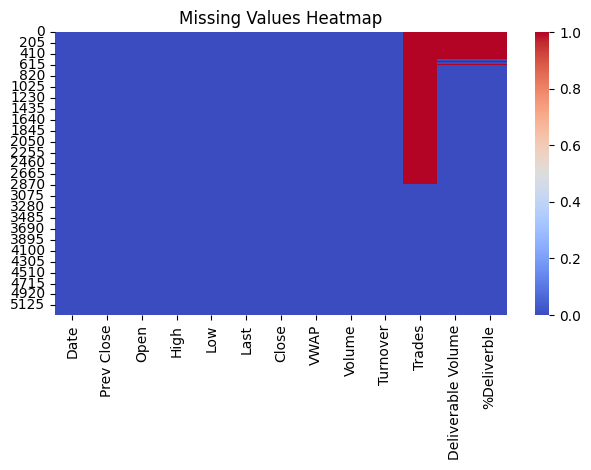

In [14]:
# Checking the null values using heatmap
sns.heatmap(df.isnull(), cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

In [15]:
# total NULL values per column 
df.isnull().sum()

Date                     0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
%Deliverble            509
dtype: int64

In [16]:
df['Trades'] = pd.to_numeric(df['Trades'], errors = 'coerce')
df['Trades'] = df['Trades'].fillna(df['Trades'].median())

In [17]:
df.isnull().sum()

Date                    0
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                  0
Deliverable Volume    509
%Deliverble           509
dtype: int64


NaN counts AFTER filling: 0


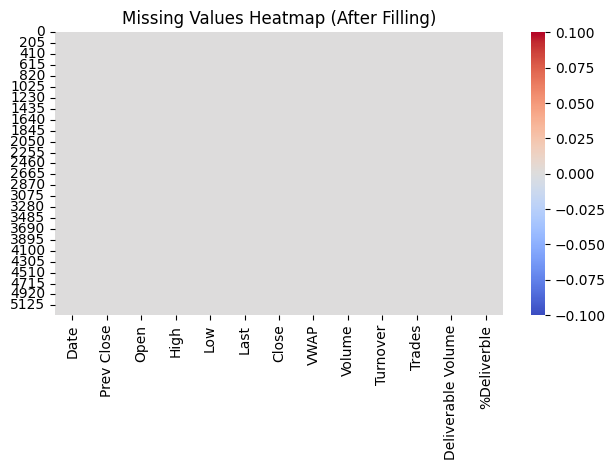

In [18]:
#Using Forward-Fill and Backward-Fill 

df.ffill(inplace=True)
df.bfill(inplace=True)
print("\nNaN counts AFTER filling:", df.isnull().sum().sum())

sns.heatmap(df.isnull(), cmap="coolwarm")
plt.title("Missing Values Heatmap (After Filling)")
plt.tight_layout()
plt.show()

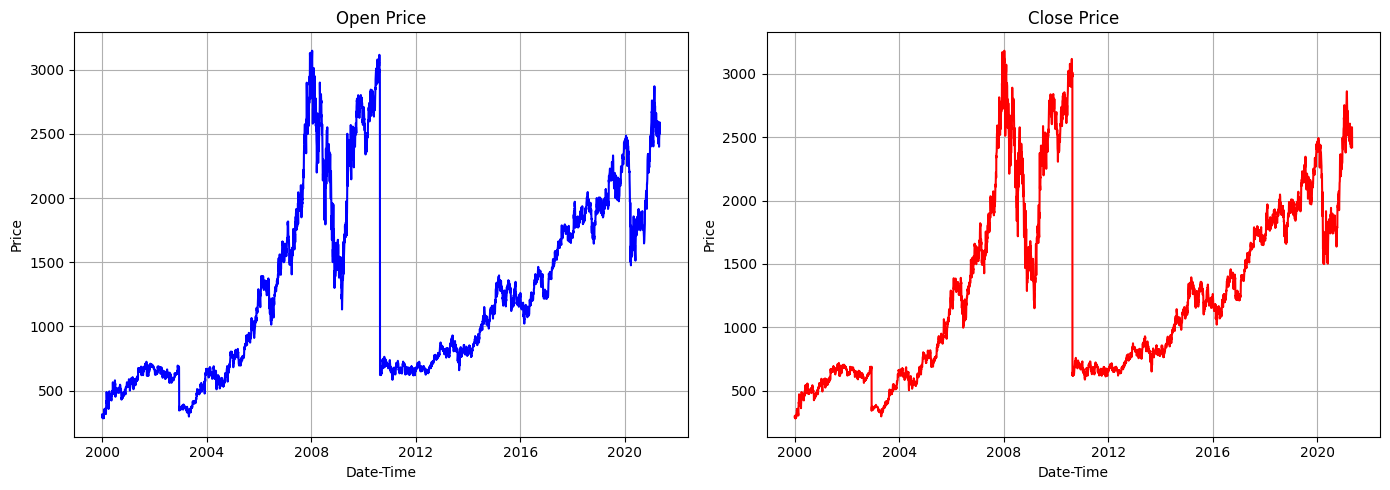

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['Date'], df['Open'],  color='blue')
axes[0].set_title('Open Price')
axes[0].set_xlabel('Date-Time')
axes[0].set_ylabel('Price')
axes[0].grid()

axes[1].plot(df['Date'], df['Close'], color='red')
axes[1].set_title('Close Price')
axes[1].set_xlabel('Date-Time')
axes[1].set_ylabel('Price')
axes[1].grid()

plt.tight_layout()
plt.show()

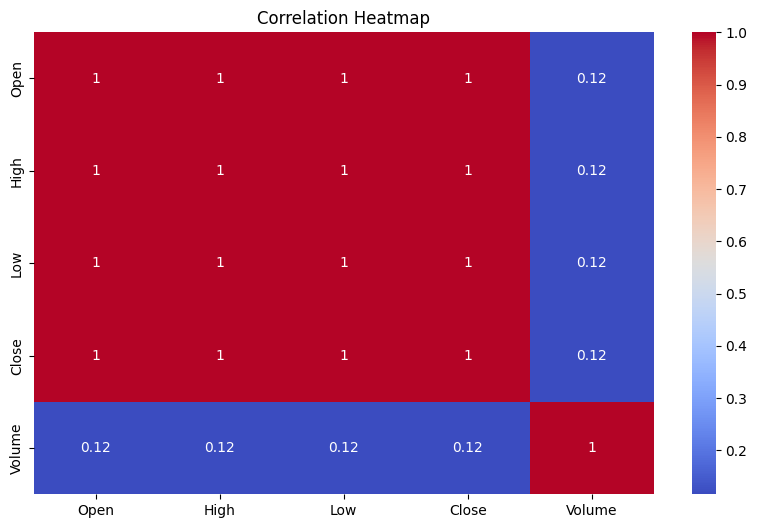

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

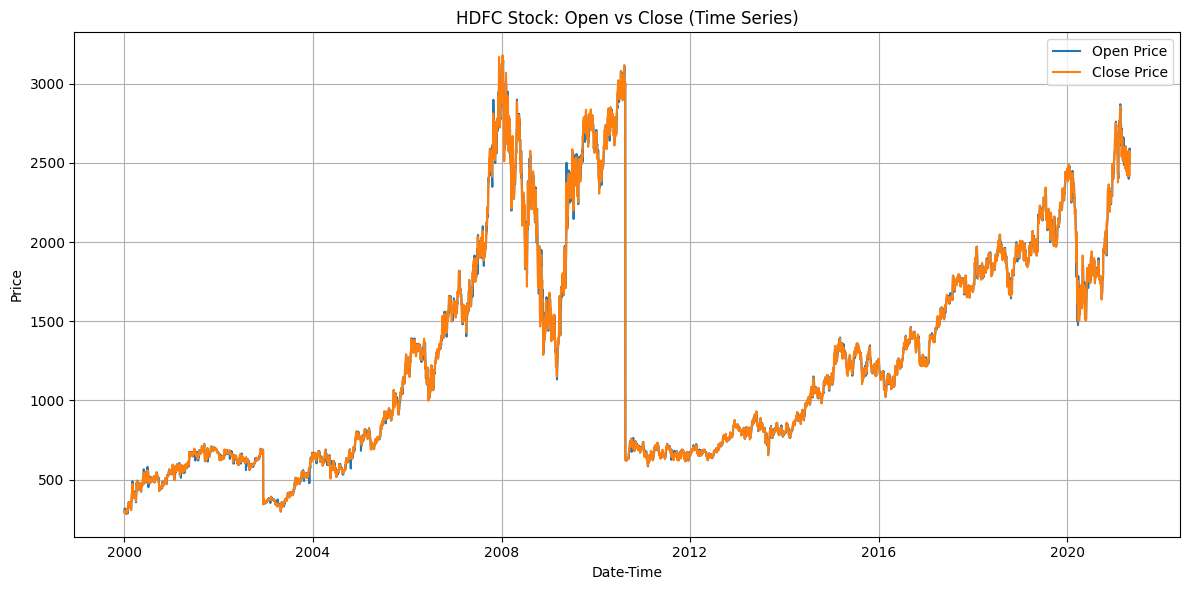

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Open'],  label='Open Price')
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.xlabel('Date-Time')
plt.ylabel('Price')
plt.title('HDFC Stock: Open vs Close (Time Series)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Feature Selection and Scaling

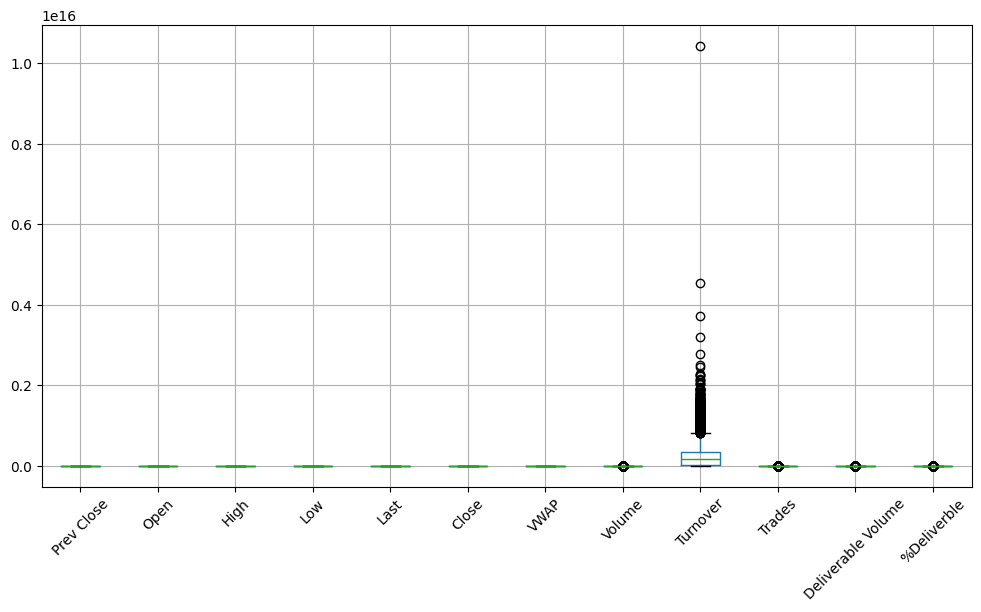

In [22]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [23]:
# Save dates
dates_all = df["Date"].copy()

# Keep same file-format style, but use all 11 features
feature_cols = ['Prev Close', 'Open', 'High', 'Low', 'Last',
                'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', '%Deliverble']

df_model = df[feature_cols].copy()

# numeric conversion
for col in df_model.columns:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# fill missing values
df_model['Trades'] = df_model['Trades'].fillna(df_model['Trades'].median())
df_model['%Deliverble'] = df_model['%Deliverble'].fillna(df_model['%Deliverble'].median())

# log-transform skewed columns
log_cols = ['Volume', 'Turnover', 'Trades']
for col in log_cols:
    df_model[col] = np.log1p(df_model[col])

df_model = df_model.astype(np.float32)

print(df_model.head())
print(df_model.shape)

   Prev Close   Open        High    Low        Last       Close        VWAP  \
0  271.750000  293.5  293.500000  293.5  293.500000  293.500000  293.500000   
1  293.500000  317.0  317.000000  297.0  304.000000  304.049988  303.619995   
2  304.049988  290.0  303.899994  285.0  295.000000  292.799988  294.529999   
3  292.799988  301.0  314.000000  295.0  296.000000  296.450012  300.140015   
4  296.450012  290.0  296.350006  281.0  287.100006  286.549988  288.799988   

      Volume   Turnover     Trades  %Deliverble  
0  10.032101  27.226860  11.412066       0.6098  
1  12.450006  29.678711  11.412066       0.6098  
2  12.502793  29.701090  11.412066       0.6098  
3  12.631069  29.848230  11.412066       0.6098  
4  12.191162  29.369816  11.412066       0.6098  
(5306, 11)


In [24]:
dates_all

0      2000-01-03
1      2000-01-04
2      2000-01-05
3      2000-01-06
4      2000-01-07
          ...    
5301   2021-04-26
5302   2021-04-27
5303   2021-04-28
5304   2021-04-29
5305   2021-04-30
Name: Date, Length: 5306, dtype: datetime64[ns]

In [25]:
df_model

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,%Deliverble
0,271.750000,293.500000,293.500000,293.500000,293.500000,293.500000,293.500000,10.032101,27.226860,11.412066,0.6098
1,293.500000,317.000000,317.000000,297.000000,304.000000,304.049988,303.619995,12.450006,29.678711,11.412066,0.6098
2,304.049988,290.000000,303.899994,285.000000,295.000000,292.799988,294.529999,12.502793,29.701090,11.412066,0.6098
3,292.799988,301.000000,314.000000,295.000000,296.000000,296.450012,300.140015,12.631069,29.848230,11.412066,0.6098
4,296.450012,290.000000,296.350006,281.000000,287.100006,286.549988,288.799988,12.191162,29.369816,11.412066,0.6098
...,...,...,...,...,...,...,...,...,...,...,...
5301,2497.350098,2500.000000,2534.100098,2483.199951,2502.000000,2509.800049,2508.070068,15.180604,34.520798,11.703786,0.6232
5302,2509.800049,2494.149902,2526.800049,2486.250000,2514.000000,2518.399902,2509.179932,14.528852,33.869488,11.535186,0.5100
5303,2518.399902,2516.100098,2609.000000,2508.300049,2575.000000,2577.000000,2574.209961,15.041478,34.407703,11.673564,0.5327
5304,2577.000000,2590.899902,2628.000000,2533.000000,2539.699951,2538.850098,2569.649902,14.915944,34.280392,11.796803,0.4901


In [26]:
data = df_model.values
indices = df_model.index.values

In [27]:
#Spliting the data into 80-20 ratio for training and testing respectively
train_size_raw = int(len(data) * 0.8)
train_data=data[:train_size_raw]
test_data=data[train_size_raw:]
train_index=df.index[:train_size_raw]
test_index=df.index[train_size_raw:]


In [28]:
train_data

array([[2.71750000e+02, 2.93500000e+02, 2.93500000e+02, ...,
        2.72268600e+01, 1.14120655e+01, 6.09799981e-01],
       [2.93500000e+02, 3.17000000e+02, 3.17000000e+02, ...,
        2.96787109e+01, 1.14120655e+01, 6.09799981e-01],
       [3.04049988e+02, 2.90000000e+02, 3.03899994e+02, ...,
        2.97010899e+01, 1.14120655e+01, 6.09799981e-01],
       ...,
       [1.22355005e+03, 1.22500000e+03, 1.22794995e+03, ...,
        3.34166794e+01, 1.12771149e+01, 7.30599999e-01],
       [1.21725000e+03, 1.22469995e+03, 1.23300000e+03, ...,
        3.27434082e+01, 1.11662292e+01, 5.85600019e-01],
       [1.23005005e+03, 1.23400000e+03, 1.24294995e+03, ...,
        3.28315544e+01, 1.11779280e+01, 6.16400003e-01]],
      shape=(4244, 11), dtype=float32)

In [29]:
test_data

array([[1.22109998e+03, 1.22494995e+03, 1.25059998e+03, ...,
        3.32111855e+01, 1.12119284e+01, 6.36300027e-01],
       [1.24750000e+03, 1.24509998e+03, 1.26400000e+03, ...,
        3.29910393e+01, 1.06356869e+01, 7.41800010e-01],
       [1.25690002e+03, 1.25834998e+03, 1.26100000e+03, ...,
        3.26256371e+01, 1.06590462e+01, 6.24899983e-01],
       ...,
       [2.51839990e+03, 2.51610010e+03, 2.60900000e+03, ...,
        3.44077034e+01, 1.16735640e+01, 5.32700002e-01],
       [2.57700000e+03, 2.59089990e+03, 2.62800000e+03, ...,
        3.42803917e+01, 1.17968025e+01, 4.90099996e-01],
       [2.53885010e+03, 2.50310010e+03, 2.52500000e+03, ...,
        3.49264717e+01, 1.23214302e+01, 6.37199998e-01]],
      shape=(1062, 11), dtype=float32)

In [30]:
"""
We use MinMaxScaler instead of StandardScaler because it keeps the data in a fixed range, 
making it easier for models like LSTM to learn patterns over time.
"""

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [31]:
train_scaled

array([[0.        , 0.00331704, 0.00100959, ..., 0.11796165, 0.7981911 ,
        0.56387866],
       [0.00747833, 0.01152235, 0.00891805, ..., 0.3418975 , 0.7981911 ,
        0.56387866],
       [0.01110575, 0.00209498, 0.0045095 , ..., 0.34394145, 0.7981911 ,
        0.56387866],
       ...,
       [0.327259  , 0.32856143, 0.31548038, ..., 0.68329906, 0.77441597,
        0.70266545],
       [0.32509285, 0.32845667, 0.3171799 , ..., 0.62180686, 0.75488067,
        0.5360754 ],
       [0.32949388, 0.3317039 , 0.32052836, ..., 0.62985754, 0.7569417 ,
        0.5714614 ]], shape=(4244, 11), dtype=float32)

In [32]:
test_scaled

array([[0.32641655, 0.32854396, 0.3231028 , ..., 0.6645305 , 0.7629317 ,
        0.59432447],
       [0.33549374, 0.33557957, 0.32761234, ..., 0.6444237 , 0.661412  ,
        0.7155331 ],
       [0.33872575, 0.340206  , 0.32660273, ..., 0.61105037, 0.66552734,
        0.581227  ],
       ...,
       [0.7724694 , 0.7793646 , 0.78024566, ..., 0.77381253, 0.8442607 ,
        0.4752987 ],
       [0.792618  , 0.8054818 , 0.7866398 , ..., 0.76218486, 0.8659723 ,
        0.42635572],
       [0.7795008 , 0.77482545, 0.7519771 , ..., 0.82119346, 0.95839906,
        0.59535843]], shape=(1062, 11), dtype=float32)

In [33]:
# Create Sequences (Multi-step ready)

BATCH_SIZE  = 64
INPUT_DAYS  = 5
OUTPUT_DAYS = 5
CLOSE_IDX   = 5
N_FEATURES = df_model.shape[1]

def create_sequences_multioutput(data, indices, input_days, output_days):
    X, y, idx = [], [], []

    for i in range(len(data) - input_days - output_days):
        X.append(data[i:i+input_days])
        y.append(data[i+input_days:i+input_days+output_days])
        idx.append(indices[i + input_days + output_days - 1])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(idx)
    )

X_train, y_train, train_index = create_sequences_multioutput(
    train_scaled, indices[:train_size_raw], INPUT_DAYS, OUTPUT_DAYS
)

X_test, y_test, test_index = create_sequences_multioutput(
    test_scaled, indices[train_size_raw:], INPUT_DAYS, OUTPUT_DAYS
)

print("X-train shape: ", X_train.shape)
print("y-train shape: ", y_train.shape)
print("X-test shape: ", X_test.shape)
print("y-test shape: ", y_test.shape)

X-train shape:  (4234, 5, 11)
y-train shape:  (4234, 5, 11)
X-test shape:  (1052, 5, 11)
y-test shape:  (1052, 5, 11)


In [34]:
# Custom Dataset for LSTM input sequences and Load data in Batches

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(SeqDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle = False)


In [35]:
# LSTM model with dropout = 0.2
class LSTMModel(nn.Module):
    def __init__(self, input_size=N_FEATURES, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_days = OUTPUT_DAYS
        self.n_features = N_FEATURES

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, OUTPUT_DAYS * N_FEATURES)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        out = out.view(-1, self.output_days, self.n_features)
        return out

model = LSTMModel().to(device)
print(model)


LSTMModel(
  (lstm): LSTM(11, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=55, bias=True)
)


In [36]:
#Training the model with parameters such as 200 epochs and learning rate 0.001 
def train_model(model, train_loader, test_loader, epochs=200, lr=1e-3, patience=20):
    criterion = nn.HuberLoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    best_loss = float("inf")
    best_weights = None
    no_improve = 0

    train_losses, val_losses = [], []

    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item() * X_b.size(0)

        train_loss = train_loss / len(train_loader.dataset)

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)

        val_loss /= len(test_loader.dataset)

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    # Loss curve
    plt.figure(figsize=(10,4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, train_losses, val_losses


Epoch 1 | Train: 0.028124 | Val: 0.004753
Epoch 2 | Train: 0.004844 | Val: 0.002693
Epoch 3 | Train: 0.004173 | Val: 0.002536
Epoch 4 | Train: 0.003314 | Val: 0.002170
Epoch 5 | Train: 0.002746 | Val: 0.002437
Epoch 6 | Train: 0.002613 | Val: 0.001847
Epoch 7 | Train: 0.002505 | Val: 0.001911
Epoch 8 | Train: 0.002411 | Val: 0.001678
Epoch 9 | Train: 0.002393 | Val: 0.002276
Epoch 10 | Train: 0.002281 | Val: 0.002514
Epoch 11 | Train: 0.002223 | Val: 0.001837
Epoch 12 | Train: 0.002155 | Val: 0.001683
Epoch 13 | Train: 0.002036 | Val: 0.001969
Epoch 14 | Train: 0.002004 | Val: 0.001987
Epoch 15 | Train: 0.001960 | Val: 0.001502
Epoch 16 | Train: 0.001924 | Val: 0.001438
Epoch 17 | Train: 0.001933 | Val: 0.001542
Epoch 18 | Train: 0.001922 | Val: 0.001602
Epoch 19 | Train: 0.001959 | Val: 0.001563
Epoch 20 | Train: 0.001927 | Val: 0.001457
Epoch 21 | Train: 0.001864 | Val: 0.001261
Epoch 22 | Train: 0.001844 | Val: 0.001248
Epoch 23 | Train: 0.001873 | Val: 0.001362
Epoch 24 | Train: 0.

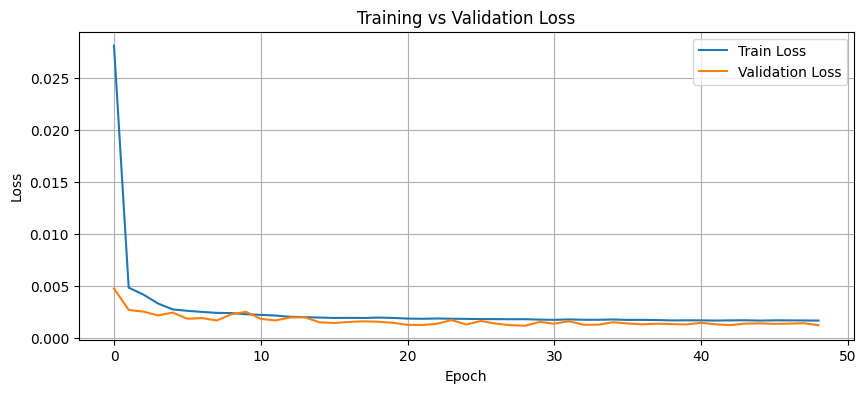

In [37]:
# Calling the train model
model, train_losses, val_losses = train_model(model, train_loader, test_loader)

In [38]:
# Evaluation 

def evaluate_model_all_features(model, Xtest, ytest, scaler, feature_names):
    model.eval()

    Xtest_tensor = torch.tensor(Xtest, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds_scaled = model(Xtest_tensor).cpu().numpy()   # (samples, OUTPUTDAYS, N_FEATURES)

    n_samples, out_days, n_features = preds_scaled.shape

    preds_scaled_2d = preds_scaled.reshape(-1, n_features)
    ytest_2d        = ytest.reshape(-1, n_features)

    preds_orig_2d = scaler.inverse_transform(preds_scaled_2d)
    y_orig_2d     = scaler.inverse_transform(ytest_2d)

    preds_orig = preds_orig_2d.reshape(n_samples, out_days, n_features)
    y_orig     = y_orig_2d.reshape(n_samples, out_days, n_features)

    print("\nFeature-wise Metrics:\n")
    for i, col in enumerate(feature_names):
        mse =  mean_squared_error(y_orig_2d[:, i], preds_orig_2d[:, i])
        rmse = np.sqrt(mean_squared_error(y_orig_2d[:, i], preds_orig_2d[:, i]))
        mae  = mean_absolute_error(y_orig_2d[:, i], preds_orig_2d[:, i])
        r2   = r2_score(y_orig_2d[:, i], preds_orig_2d[:, i])

        print(f"{col:15s} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

    overall_mse = mean_squared_error(y_orig_2d, preds_orig_2d)
    overall_rmse = np.sqrt(mean_squared_error(y_orig_2d, preds_orig_2d))
    overall_mae  = mean_absolute_error(y_orig_2d, preds_orig_2d)
    overall_r2   = r2_score(y_orig_2d, preds_orig_2d)

    print("\nOverall Metrics:")
    print("MSE :", overall_mse)
    print("RMSE:", overall_rmse)
    print("MAE :", overall_mae)
    print("R2  :", overall_r2)

    return preds_scaled, preds_orig, y_orig

In [39]:
# calling the evaluation function 

feature_names = df_model.columns.tolist()

preds_scaled, preds_orig, y_orig = evaluate_model_all_features(model, X_test, y_test, scaler, feature_names)


Feature-wise Metrics:

Prev Close      | MSE: 3321.7625 | RMSE: 57.6347 | MAE: 39.7662 | R2: 0.9649
Open            | MSE: 3654.1421 | RMSE: 60.4495 | MAE: 41.0447 | R2: 0.9614
High            | MSE: 3935.2114 | RMSE: 62.7313 | MAE: 46.0030 | R2: 0.9591
Low             | MSE: 4407.9150 | RMSE: 66.3921 | MAE: 46.5775 | R2: 0.9519
Last            | MSE: 4330.8340 | RMSE: 65.8091 | MAE: 46.4876 | R2: 0.9541
Close           | MSE: 4461.0444 | RMSE: 66.7911 | MAE: 47.1830 | R2: 0.9528
VWAP            | MSE: 3918.5063 | RMSE: 62.5980 | MAE: 43.8594 | R2: 0.9582
Volume          | MSE: 0.3747 | RMSE: 0.6121 | MAE: 0.4858 | R2: -0.3041
Turnover        | MSE: 0.3567 | RMSE: 0.5972 | MAE: 0.4705 | R2: -0.0874
Trades          | MSE: 0.2154 | RMSE: 0.4642 | MAE: 0.3573 | R2: -0.0062
%Deliverble     | MSE: 0.0081 | RMSE: 0.0903 | MAE: 0.0725 | R2: 0.4481

Overall Metrics:
MSE : 2548.215087890625
RMSE: 50.47984833466346
MAE : 28.39160919189453
R2  : 0.613883912563324


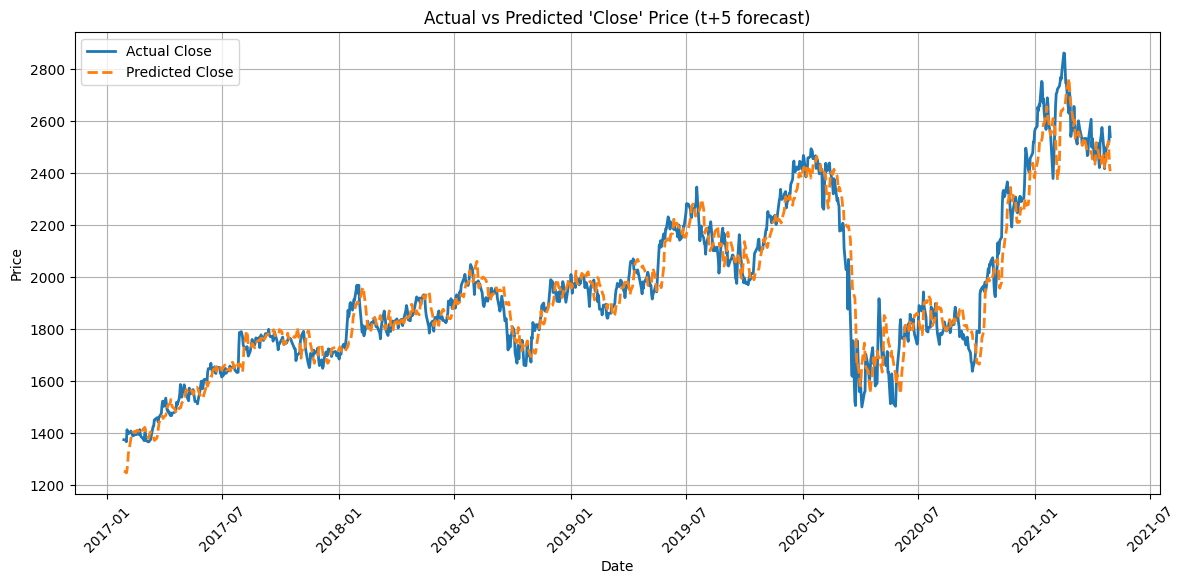

In [40]:
# CLOSE Feature (Actual vs Predicted) 
plt.figure(figsize=(14, 6))
feat_idx = feature_names.index("Close")
dates = dates_all.iloc[test_index]

plt.plot(dates, y_orig[:, -1, feat_idx], label="Actual Close", linewidth=2)
plt.plot(dates, preds_orig[:, -1, feat_idx], label="Predicted Close", linestyle="--", linewidth=2)

plt.title("Actual vs Predicted 'Close' Price (t+5 forecast)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

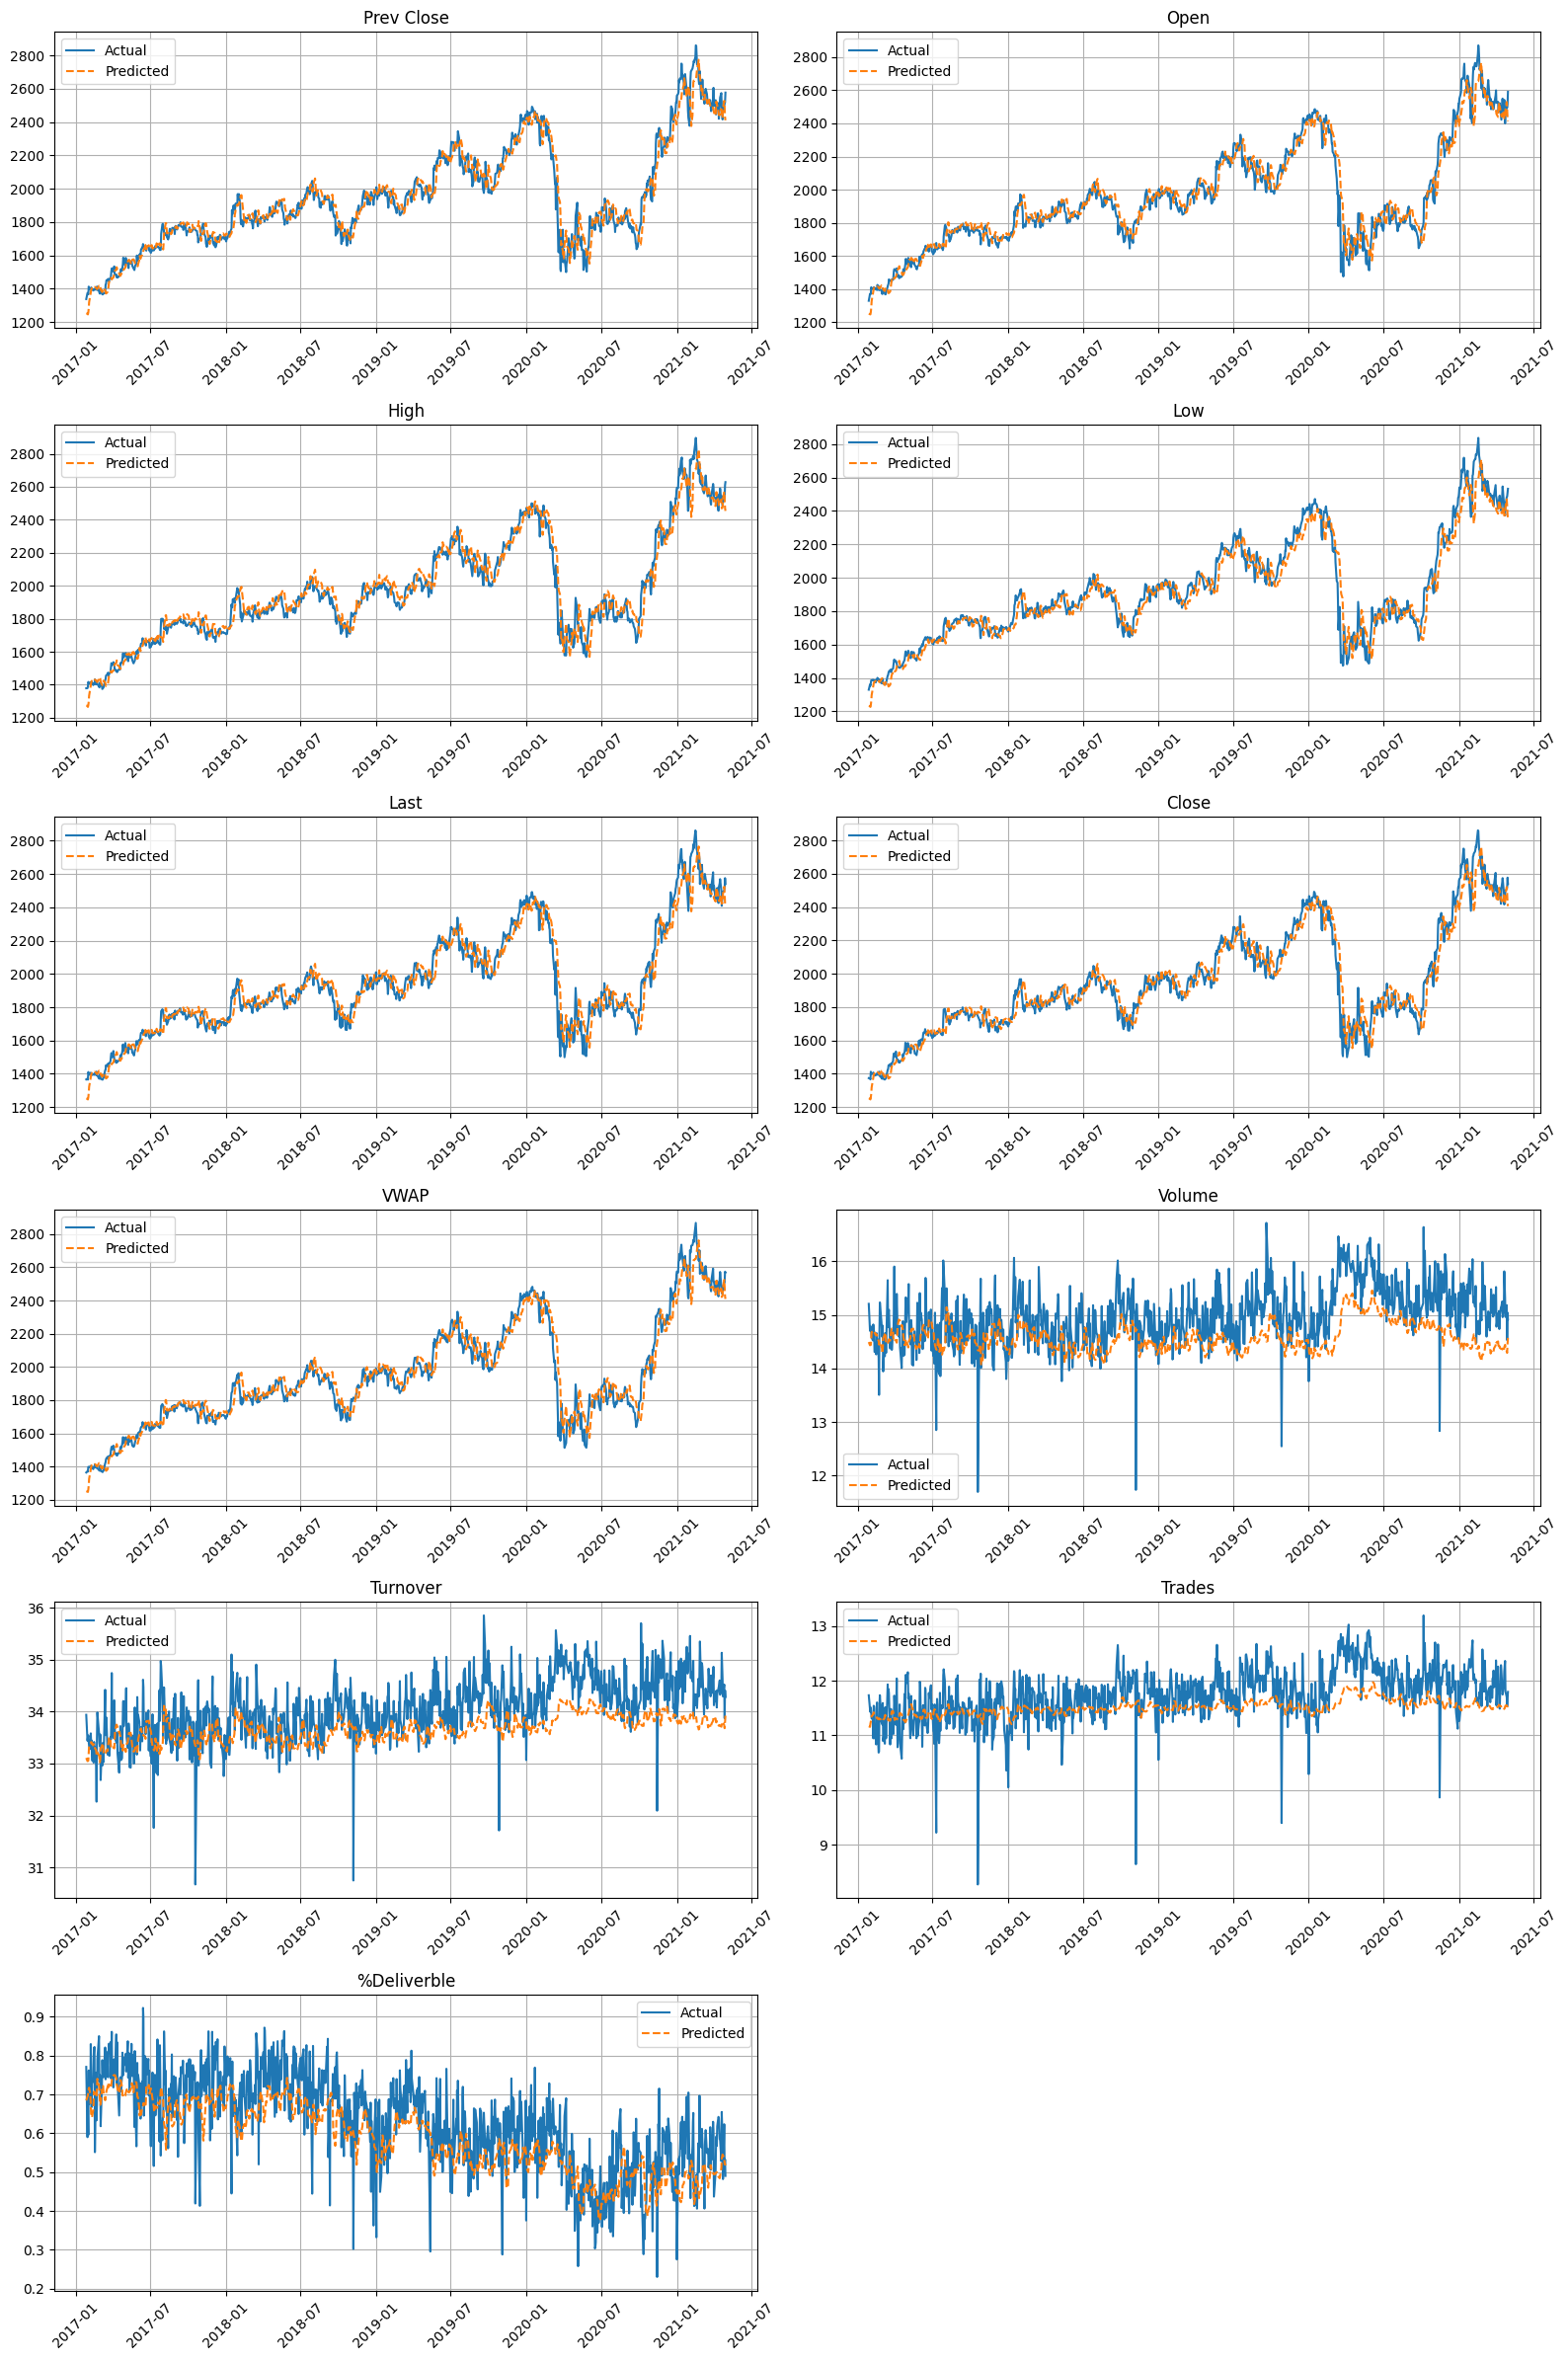

In [41]:
# Subplot for all 11 features (according to the dates)
n_features = len(feature_names)
n_rows = (n_features + 1) // 2 
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows))
axes = axes.flatten()

dates = dates_all.iloc[test_index]

for i, col in enumerate(feature_names):
    ax = axes[i]
    ax.plot(dates, y_orig[:, -1, i], label="Actual", linewidth=1.5)
    ax.plot(dates, preds_orig[:, -1, i], label="Predicted", linestyle="--", linewidth=1.5)
    ax.set_title(col)
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# remove empty subplot if odd number of features
if n_features % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [43]:
"""
=========================================================
  HDFC LSTM Model — Save & Load with Pickle
  Run this AFTER training your model in the notebook
=========================================================
"""

import pickle
import torch
import numpy as np


model_bundle = {

    "model_state_dict": model.state_dict(),

    # Scaler fitted on training data
    "scaler": scaler,

    # Hyperparameters to re-build the architecture
    "hyperparams": {
        "input_size":   N_FEATURES,
        "hidden_size":  128,
        "num_layers":   2,
        "dropout":      0.2,
        "INPUT_DAYS":   INPUT_DAYS,
        "OUTPUT_DAYS":  OUTPUT_DAYS,
        "BATCH_SIZE":   BATCH_SIZE,
        "CLOSE_IDX":    CLOSE_IDX,
        "N_FEATURES":   N_FEATURES,
    },

    # Feature column names 
    "feature_names": feature_names,

    # Train / Val loss history
    "train_losses": train_losses,
    "val_losses":   val_losses,

    # Test-set predictions & actuals (inverse-scaled, original price space)
    "preds_orig":   preds_orig,   # shape: (samples, OUTPUT_DAYS, N_FEATURES)
    "y_orig":       y_orig,       # shape: (samples, OUTPUT_DAYS, N_FEATURES)

    # Date index aligned to test set
    "test_dates":   dates_all.iloc[test_index].values,
}

# ── 2. Save ─────────────────────────────────────────────────────────────────────
SAVE_PATH = "hdfc_lstm_bundle.pkl"

with open(SAVE_PATH, "wb") as f:
    pickle.dump(model_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f" Model bundle saved → {SAVE_PATH}")


# ══════════════════════════════════════════════════════════════════════════════
#  HOW TO LOAD BACK (in a new script / Streamlit app)
# ══════════════════════════════════════════════════════════════════════════════

def load_bundle(path: str = "hdfc_lstm_bundle.pkl"):
    """Load the saved bundle and reconstruct the LSTM model."""
    import pickle, torch

    with open(path, "rb") as f:
        bundle = pickle.load(f)

    # Re-build the model architecture with saved hyperparams
    hp = bundle["hyperparams"]

    # (make sure LSTMModel class is importable / defined before calling this)
    restored_model = LSTMModel(
        input_size  = hp["input_size"],
        hidden_size = hp["hidden_size"],
        num_layers  = hp["num_layers"],
        dropout     = hp["dropout"],
    )
    restored_model.load_state_dict(bundle["model_state_dict"])
    restored_model.eval()

    print("  Bundle loaded successfully.")
    print(f"    Features  : {bundle['feature_names']}")
    print(f"    Pred shape: {bundle['preds_orig'].shape}")

    return restored_model, bundle


# Uncomment to test round-trip:
# restored_model, bundle = load_bundle()

 Model bundle saved → hdfc_lstm_bundle.pkl
